In [1]:
%run ../../../bootstrap.py


[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [3]:
from src.data.dataset_builder import DatasetBuilder
from src.data.dataset import KidneyStoneDataset
from src.pipelines.resnet50_pipeline import resnet50
from src.data.dataset_builder import DatasetBuilder, assign_task_labels

import pandas as pd


In [4]:
patches_df_full = pd.read_csv(f"experiments/patches_{PATCH_SIZE}_metadata.csv")
task_name= "binario"
task_config= TASKS[task_name]
patches_task = assign_task_labels(patches_df_full, task_config)

resnet50_model= resnet50(patches_task, Case.PATCH)


EXPERIMENTO K-FOLD: resnet50_binario
Total patchs: 5290
K-folds: 5 | Validación interna: 15% del train

--- Fold 1/5 ---
  Train: 3635 patchs (214 cálculos)
  Val:   627 patchs (35 cálculos)
  Test:  1028 patchs (62 cálculos)
Device: cuda
Trainable parameters: 525,570
Epochs: 30, LR: 0.0001, Weight decay: 0.0001
Epoch   1/30 | train: loss=0.4662 acc=0.7742 f1=0.7736 | val: loss=0.5041 acc=0.7608 f1=0.7582 | lr=1.00e-04 | 9.3s
Epoch   2/30 | train: loss=0.3967 acc=0.8235 f1=0.8235 | val: loss=0.4839 acc=0.7687 f1=0.7619 | lr=1.00e-04 | 8.8s
Epoch   3/30 | train: loss=0.3653 acc=0.8422 f1=0.8422 | val: loss=0.4488 acc=0.8086 f1=0.8048 | lr=1.00e-04 | 8.8s
Epoch   4/30 | train: loss=0.3563 acc=0.8444 f1=0.8444 | val: loss=0.4714 acc=0.8054 f1=0.7974 | lr=1.00e-04 | 8.8s
Epoch   5/30 | train: loss=0.3389 acc=0.8604 f1=0.8604 | val: loss=0.4827 acc=0.8086 f1=0.8020 | lr=1.00e-04 | 8.7s
Epoch   6/30 | train: loss=0.3280 acc=0.8532 f1=0.8532 | val: loss=0.4650 acc=0.8134 f1=0.8073 | lr=1.00e

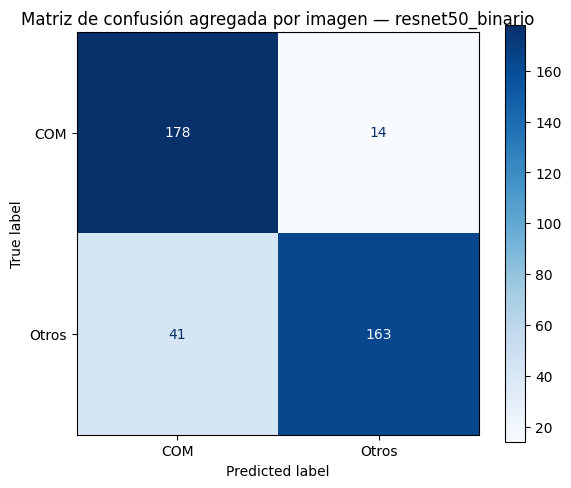

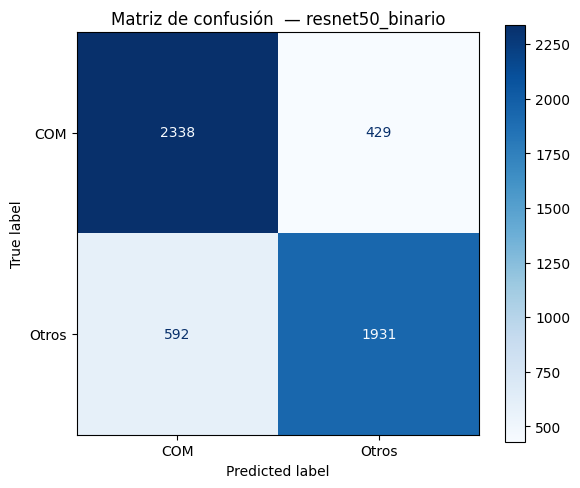


RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8079 ± 0.0301
  auc_weighted: 0.8980 ± 0.0196
  f1_weighted: 0.8075 ± 0.0309
  npv_weighted: 0.8047 ± 0.0243
  precision_weighted: 0.8147 ± 0.0294
  recall_weighted: 0.8079 ± 0.0301
  specificity_weighted: 0.8087 ± 0.0343


In [5]:
config = {
            "name": f"resnet50_{task_name}",
            "output_dir": f"experiments/resnet50/resnet50_patches/resnet50_{task_name}",
            "class_names": task_config["class_names"],
            "batch_size": 16
        }
        

resnet50_model.run_model(config, show_fold_metrics= True)